In [4]:
import pandas as pd
import numpy as np
import multiprocessing as mp
import dask
import datetime
import dask.dataframe as dd
import dask.array as da
import dask.bag as bd 
from dask.distributed import Client, progress
import matplotlib.pyplot as plt
import time
import plotly.express as px
import pyarrow.parquet as pq
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from dask_ml.model_selection import train_test_split
import statsmodels.api as sm

In [5]:
#Data cleaning - Trips_By_Distance
#dataset1
Trips_D = pd.read_csv ("Trips_by_Distance.csv")
Trips_D.head()


,Level,Date,State FIPS,State Postal Code,County FIPS,County Name,Population Staying at Home,Population Not Staying at Home,Number of Trips,Number of Trips <1,...,Number of Trips 5-10,Number of Trips 10-25,Number of Trips 25-50,Number of Trips 50-100,Number of Trips 100-250,Number of Trips 250-500,Number of Trips >=500,Row ID,Week,Month
0,National,1/1/2019,NaN,NaN,NaN,NaN,77433867.0,248733553.0,8.977844e+08,241667151.0,...,129670778.0,116904343.0,40432062.0,15686639.0,7525563.0,1806022.0,1728112.0,00-00000-20190101,0,1
1,National,1/2/2019,NaN,NaN,NaN,NaN,61305201.0,264862219.0,1.139452e+09,291276735.0,...,171637514.0,167412698.0,56148976.0,17739183.0,7817044.0,1962301.0,1531219.0,00-00000-20190102,0,1
2,National,1/3/2019,NaN,NaN,NaN,NaN,63050480.0,263116940.0,1.162753e+09,296375014.0,...,175775410.0,172027487.0,57632422.0,18366626.0,8124548.0,2038099.0,1567072.0,00-00000-20190103,0,1
3,National,1/4/2019,NaN,NaN,NaN,NaN,61803652.0,264363768.0,1.181954e+09,293159631.0,...,181324645.0,176144493.0,58761592.0,19315785.0,8687318.0,2096065.0,1569185.0,00-00000-20190104,0,1
4,National,1/5/2019,NaN,NaN,NaN,NaN,64389745.0,261777675.0,1.180477e+09,295459014.0,...,180941769.0,165239790.0,54842134.0,19363939.0,8490791.0,1991159.0,1438664.0,00-00000-20190105,0,1


In [6]:
#Read and displays the dataset
Trips_D.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Level                           1048575 non-null  object 
 1   Date                            1048575 non-null  object 
 2   State FIPS                      1047674 non-null  float64
 3   State Postal Code               1047674 non-null  object 
 4   County FIPS                     1001723 non-null  float64
 5   County Name                     1001723 non-null  object 
 6   Population Staying at Home      1035625 non-null  float64
 7   Population Not Staying at Home  1035625 non-null  float64
 8   Number of Trips                 1035625 non-null  float64
 9   Number of Trips <1              1035625 non-null  float64
 10  Number of Trips 1-3             1035625 non-null  float64
 11  Number of Trips 3-5             1035625 non-null  float64
 12  

In [7]:
#checks for number of duplicate rows and if its zero then no need to drop duplicates
Trips_D.duplicated().sum() 

0

In [8]:
#check how many missing values in the dataset
Trips_D.isna().sum()

Level                                 0
Date                                  0
State FIPS                          901
State Postal Code                   901
County FIPS                       46852
County Name                       46852
Population Staying at Home        12950
Population Not Staying at Home    12950
Number of Trips                   12950
Number of Trips <1                12950
Number of Trips 1-3               12950
Number of Trips 3-5               12950
Number of Trips 5-10              12950
Number of Trips 10-25             12950
Number of Trips 25-50             12950
Number of Trips 50-100            12950
Number of Trips 100-250           12950
Number of Trips 250-500           12950
Number of Trips >=500             12950
Row ID                                0
Week                                  0
Month                                 0
dtype: int64

In [9]:
#remove rows with missing values
Trips_D_clean = Trips_D.dropna()

#re-checks for missing values in the clean dataset
Trips_D_clean.isna().sum()

Level                             0
Date                              0
State FIPS                        0
State Postal Code                 0
County FIPS                       0
County Name                       0
Population Staying at Home        0
Population Not Staying at Home    0
Number of Trips                   0
Number of Trips <1                0
Number of Trips 1-3               0
Number of Trips 3-5               0
Number of Trips 5-10              0
Number of Trips 10-25             0
Number of Trips 25-50             0
Number of Trips 50-100            0
Number of Trips 100-250           0
Number of Trips 250-500           0
Number of Trips >=500             0
Row ID                            0
Week                              0
Month                             0
dtype: int64

In [10]:
#using pandas to convert date column to datetime
Trips_D_clean['Date'] = pd.to_datetime(Trips_D_clean['Date'])

C:\Users\purvi\AppData\Local\Temp\ipykernel_17204\2981112353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Trips_D_clean['Date'] = pd.to_datetime(Trips_D_clean['Date'])


In [11]:
#checks for datatypes of the columns
Trips_D_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 988773 entries, 21061 to 1048574
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Level                           988773 non-null  object        
 1   Date                            988773 non-null  datetime64[ns]
 2   State FIPS                      988773 non-null  float64       
 3   State Postal Code               988773 non-null  object        
 4   County FIPS                     988773 non-null  float64       
 5   County Name                     988773 non-null  object        
 6   Population Staying at Home      988773 non-null  float64       
 7   Population Not Staying at Home  988773 non-null  float64       
 8   Number of Trips                 988773 non-null  float64       
 9   Number of Trips <1              988773 non-null  float64       
 10  Number of Trips 1-3             988773 non-null  float64

In [12]:
Trips_d = dd.read_csv("Trips_by_Distance.csv")
Trips_D_clean['Week'].nunique()


45

In [13]:
Trips_D_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 988773 entries, 21061 to 1048574
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Level                           988773 non-null  object        
 1   Date                            988773 non-null  datetime64[ns]
 2   State FIPS                      988773 non-null  float64       
 3   State Postal Code               988773 non-null  object        
 4   County FIPS                     988773 non-null  float64       
 5   County Name                     988773 non-null  object        
 6   Population Staying at Home      988773 non-null  float64       
 7   Population Not Staying at Home  988773 non-null  float64       
 8   Number of Trips                 988773 non-null  float64       
 9   Number of Trips <1              988773 non-null  float64       
 10  Number of Trips 1-3             988773 non-null  float64

In [14]:
#question 1 a)
people_home_pw = Trips_D_clean.groupby('Week')['Population Staying at Home'].mean()

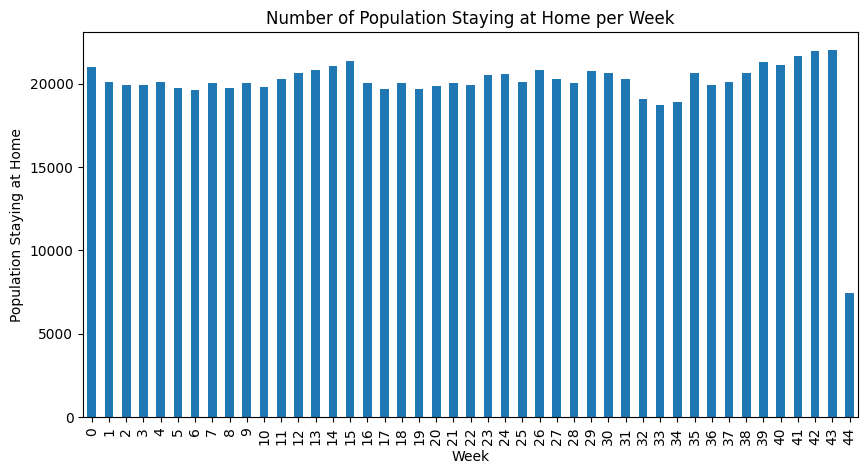

In [15]:
people_home_pw.plot (kind='bar', figsize=(10, 5))
plt.xlabel('Week')
plt.ylabel('Population Staying at Home')
plt.title('Number of Population Staying at Home per Week')
plt.show()

In [16]:
people_home_pw.describe()

count       45.000000
mean     20018.020588
std       2041.349724
min       7465.212121
25%      19889.436675
50%      20077.207573
75%      20662.342080
max      21998.566027
Name: Population Staying at Home, dtype: float64

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Population Staying at Home  0 non-null      float64       
 1   Date                        0 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 0.0 bytes


C:\Users\purvi\AppData\Local\Temp\ipykernel_17204\3992221722.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_national_pd, x='Date', y='Population Staying at Home', palette='viridis').set_title('Population Staying at Home per Year')


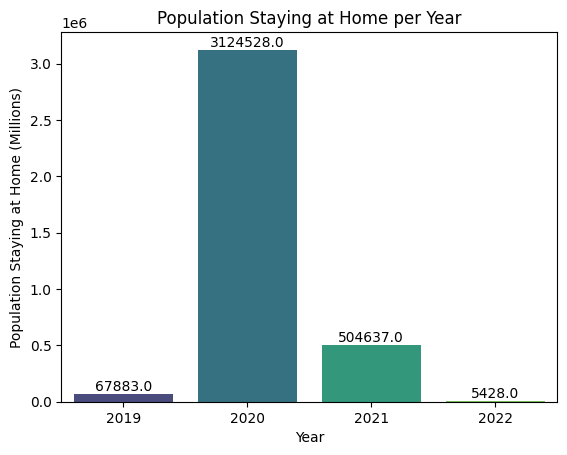

In [17]:
import seaborn as sns #proof for covid times
df_national = Trips_D_clean[Trips_D_clean['Level'] == 'National'][['Population Staying at Home', 'Date']]
df_national.info()
df_national = dd.read_csv("Trips_by_Distance.csv", dtype={'Population Staying at Home': 'float64'})
df_national['Date'] = dd.to_datetime(df_national['Date'])
avg_national = df_national.groupby(df_national['Date'].dt.year)['Population Staying at Home'].mean() 
avg_national = avg_national.reset_index() 
avg_national_pd = avg_national.compute() 
sns.barplot(data=avg_national_pd, x='Date', y='Population Staying at Home', palette='viridis').set_title('Population Staying at Home per Year')
for index, row in avg_national.iterrows():
    plt.text(index, row['Population Staying at Home'], str(round(row['Population Staying at Home'], 0)), ha="center", va="bottom")
            
plt.xlabel('Year')
plt.ylabel('Population Staying at Home (Millions)')
plt.title ('Population Staying at Home per Year')
plt.show()

In [18]:
#1b 
df = Trips_D[['Date','Number of Trips 10-25','Number of Trips 50-100']]
trips_new = df[df['Number of Trips 10-25']>10000000]
trips_new2 = df[df['Number of Trips 50-100']>10000000]

compare = trips_new2[trips_new2['Date'].isin(trips_new['Date'])]
compare

,Date,Number of Trips 10-25,Number of Trips 50-100
0,1/1/2019,116904343.0,15686639.0
1,1/2/2019,167412698.0,17739183.0
2,1/3/2019,172027487.0,18366626.0
3,1/4/2019,176144493.0,19315785.0
4,1/5/2019,165239790.0,19363939.0
...,...,...,...
157189,6/15/2021,200549282.0,19181256.0
157190,6/16/2021,199082591.0,19247409.0
157191,6/17/2021,198280332.0,19277452.0
157192,6/18/2021,202609024.0,22229709.0


In [19]:
trips_10_25 = px.scatter(x = compare['Date'], y = compare['Number of Trips 10-25'], title='Number of Trips 10-25 miles')
trips_10_25.update_layout(xaxis_title="Date", yaxis_title="Number of Trips 10-25 (miles)")
trips_10_25.show()

In [20]:
trips_50_100 = px.scatter(x= compare['Date'], y= compare['Number of Trips 50-100'], title='Number of Trips 50-100 miles')
trips_50_100.update_layout(xaxis_title="Date", yaxis_title="Number of Trips 50-100 (miles)")
trips_50_100.show()

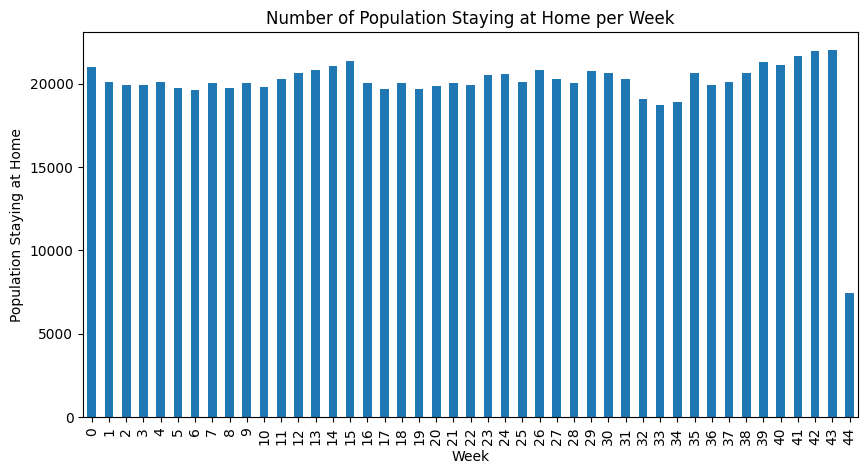




Time with 10 processors: 0.012218236923217773 seconds





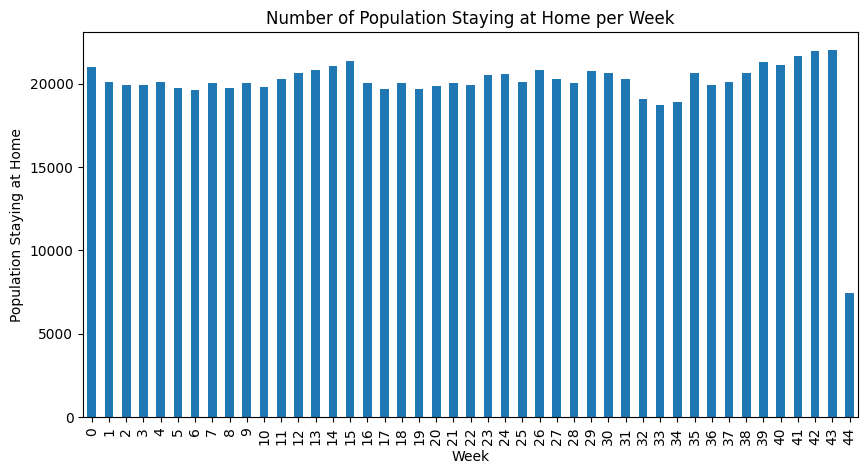




Time with 20 processors: 0.01991438865661621 seconds





In [26]:
#question 1 c) - parallel computing using dask vs pandas - efficiency (i.e. length of time) - population staying at home
N_processors = [10,20]
Time_N_processors = {}
for processor in N_processors:
    start_time = time.time()
    people_home_pw = Trips_D_clean.groupby('Week')['Population Staying at Home'].mean()
    dask_Time = time.time()-start_time
    Time_N_processors[processor] = dask_Time
    people_home_pw.plot (kind='bar', figsize=(10, 5))
    plt.xlabel('Week')
    plt.ylabel('Population Staying at Home')
    plt.title('Number of Population Staying at Home per Week')
    plt.show()
    print(f"\n\n\nTime with {processor} processors: {dask_Time} seconds\n\n\n")

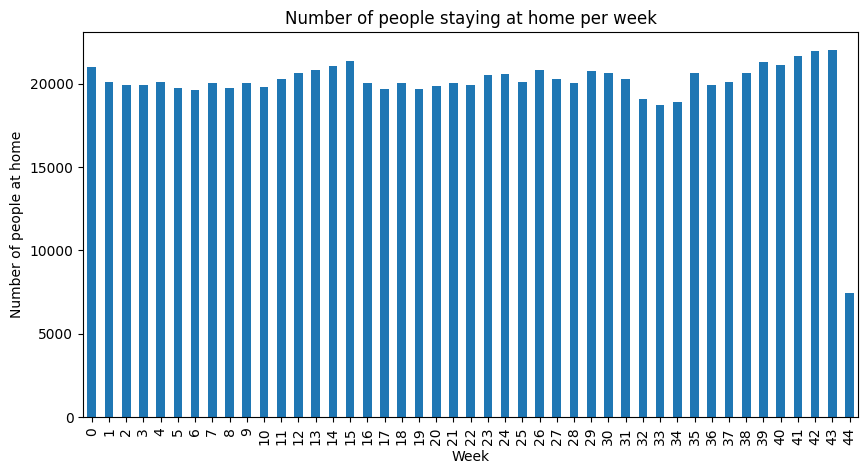

Pandas time: 0.28999781608581543seconds


In [22]:
start_time = time.time()
people_home_pw.plot(kind='bar', figsize=(10, 5))
plt.title('Number of people staying at home per week')
plt.xlabel('Week')
plt.ylabel('Number of people at home')
plt.show()
pandas_time = time.time()-start_time
print(f"Pandas time: {pandas_time}seconds")

In [32]:
N_processors = [10,20]
Time_N_processors = {}
for processor in N_processors:
    start_time = time.time()
    df = Trips_D[['Date','Number of Trips 10-25','Number of Trips 50-100']]
    trips_new = df[df['Number of Trips 10-25']>10000000]
    trips_new2 = df[df['Number of Trips 50-100']>10000000]
    compare = trips_new2[trips_new2['Date'].isin(trips_new['Date'])]
    compare
    dask_Time = time.time()-start_time
    Time_N_processors[processor] = dask_Time
    print(f"\n\n\nTime with {processor} processors: {dask_Time} seconds\n\n\n")
trips_new = df[df['Number of Trips 10-25']>10000000]
trips_10_25 = px.scatter(x = compare['Date'], y = compare['Number of Trips 10-25'], title='Number of Trips 10-25 miles')
trips_10_25.update_layout(xaxis_title="Date", yaxis_title="Number of Trips 10-25 (miles)")
trips_10_25.show()

trips_new2= df[df['Number of Trips 50-100']>10000000]
trips_50_100 = px.scatter(x= compare['Date'], y= compare['Number of Trips 50-100'], title='Number of Trips 50-100 miles')
trips_50_100.update_layout(xaxis_title="Date", yaxis_title="Number of Trips 50-100 (miles)")
trips_50_100.show()




Time with 10 processors: 0.013948678970336914 seconds






Time with 20 processors: 0.015083789825439453 seconds





In [27]:
start_time = time.time()
df = Trips_D[['Date','Number of Trips 10-25','Number of Trips 50-100']]
trips_new = df[df['Number of Trips 10-25']>10000000]
trips_new2 = df[df['Number of Trips 50-100']>10000000]

compare = trips_new2[trips_new2['Date'].isin(trips_new['Date'])]
compare
pandas_time = time.time() -start_time
print(f"Pandas time: {pandas_time}seconds")
trips_new = df[df['Number of Trips 10-25']>10000000]
trips_10_25 = px.scatter(x = compare['Date'], y = compare['Number of Trips 10-25'], title='Number of Trips 10-25 miles')
trips_10_25.update_layout(xaxis_title="Date", yaxis_title="Number of Trips 10-25 (miles)")
trips_10_25.show()

trips_new2= df[df['Number of Trips 50-100']>10000000]
trips_50_100 = px.scatter(x= compare['Date'], y= compare['Number of Trips 50-100'], title='Number of Trips 50-100 miles')
trips_50_100.update_layout(xaxis_title="Date", yaxis_title="Number of Trips 50-100 (miles)")
trips_50_100.show()

Pandas time: 0.06209993362426758seconds
